# Capítulo 5 · Medir el error: funciones de pérdida

En los cuadernos anteriores construimos cálculos con neuronas, capas y funciones de activación. En este cuaderno vamos a concentrarnos en el paso siguiente: **comparar una predicción con el valor correcto y expresar la diferencia mediante un número**.

Trabajaremos con ejemplos pequeños y parámetros ya elegidos. Todavía no entrenaremos una red ni modificaremos sus pesos.

## Objetivos del cuaderno

Al finalizar este recorrido podrás:

- comprobar por qué los errores con signo no deben promediarse directamente;
- calcular e interpretar MSE en problemas de regresión;
- calcular Binary Cross-Entropy en clasificación binaria;
- calcular Categorical Cross-Entropy en clasificación multiclase;
- distinguir una función de pérdida de una métrica como *accuracy*;
- relacionar el tipo de problema, la activación de salida y la pérdida;
- observar cómo la pérdida depende de los parámetros de un modelo sencillo.

## Importación de librerías

Usaremos NumPy para los cálculos, Pandas para organizar algunos resultados y Matplotlib para representar las pérdidas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.options.display.float_format = "{:.4f}".format

## 1. Predicción, valor real y error

El valor real se representa con $y$ y la predicción con $\hat{y}$. Una primera idea podría ser restarlos:

$$e = y-\hat{y}$$

Sin embargo, los errores positivos y negativos pueden cancelarse. Veamos un caso mínimo: dos predicciones se equivocan por la misma magnitud, pero en direcciones opuestas.

In [2]:
y_real = np.array([20, 20])
y_pred = np.array([18, 22])

errores = y_real - y_pred

comparacion_error = pd.DataFrame({
    "Valor real": y_real,
    "Predicción": y_pred,
    "Error": errores,
    "Error al cuadrado": errores ** 2,
})

display(comparacion_error)
print(f"Promedio de los errores con signo: {errores.mean():.2f}")
print(f"Promedio de los errores cuadrados: {np.mean(errores ** 2):.2f}")

,Valor real,Predicción,Error,Error al cuadrado
0,20,18,2,4
1,20,22,-2,4


Promedio de los errores con signo: 0.00
Promedio de los errores cuadrados: 4.00


El promedio de los errores con signo es `0.00`, aunque ninguna predicción es exacta. En cambio, al elevar los errores al cuadrado ambos aportan un valor positivo. Así evitamos que los desvíos se oculten al promediarlos.

## 2. MSE para regresión

El **Mean Squared Error** calcula el promedio de los errores cuadrados:

$$\operatorname{MSE}=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat{y}_i)^2$$

Vamos a comparar dos conjuntos de predicciones sobre los mismos valores reales. Además del MSE calcularemos RMSE, su raíz cuadrada, para volver a las unidades originales del objetivo.

In [3]:
y_real = np.array([10, 20, 30])
pred_modelo_a = np.array([9, 22, 27])
pred_modelo_b = np.array([10, 19, 29])

def mse(y, prediccion):
    return np.mean((y - prediccion) ** 2)

mse_a = mse(y_real, pred_modelo_a)
mse_b = mse(y_real, pred_modelo_b)

detalle_mse = pd.DataFrame({
    "Valor real": y_real,
    "Predicción A": pred_modelo_a,
    "Error² A": (y_real - pred_modelo_a) ** 2,
    "Predicción B": pred_modelo_b,
    "Error² B": (y_real - pred_modelo_b) ** 2,
})

resumen_mse = pd.DataFrame({
    "Modelo": ["A", "B"],
    "MSE": [mse_a, mse_b],
    "RMSE": [np.sqrt(mse_a), np.sqrt(mse_b)],
})

display(detalle_mse)
display(resumen_mse)

,Valor real,Predicción A,Error² A,Predicción B,Error² B
0,10,9,1,10,0
1,20,22,4,19,1
2,30,27,9,29,1


,Modelo,MSE,RMSE
0,A,4.6667,2.1602
1,B,0.6667,0.8165


El Modelo B obtiene el menor MSE: aproximadamente `0.67`, frente a `4.67` del Modelo A. Según esta función de pérdida, el segundo conjunto de predicciones se aproxima mejor a los valores reales.

El RMSE del Modelo B es aproximadamente `0.82`. A diferencia del MSE, puede interpretarse en las mismas unidades que la variable predicha. No obstante, durante el entrenamiento MSE resulta especialmente útil por su forma matemática.

### Cómo MSE penaliza los errores grandes

Para observar el efecto del cuadrado, representaremos errores de distintas magnitudes. No hace falta conocer un modelo concreto: solamente nos interesa ver cómo cambia la pérdida individual cuando aumenta la distancia entre la predicción y el valor real.

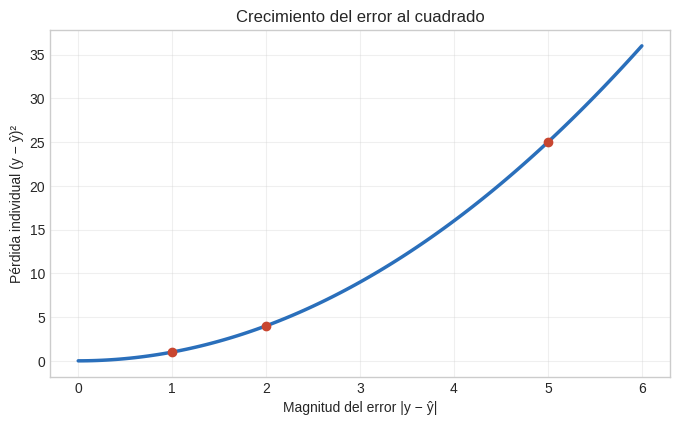

In [4]:
magnitud_error = np.linspace(0, 6, 121)
error_cuadrado = magnitud_error ** 2

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(magnitud_error, error_cuadrado, color="#2a6fbb", linewidth=2.5)
ax.scatter([1, 2, 5], [1, 4, 25], color="#c84630", zorder=3)
ax.set_title("Crecimiento del error al cuadrado")
ax.set_xlabel("Magnitud del error |y − ŷ|")
ax.set_ylabel("Pérdida individual (y − ŷ)²")
ax.grid(alpha=0.3)
plt.show()

La curva no crece de manera lineal. Un error de magnitud `5` produce una pérdida de `25`, mientras que un error de magnitud `1` produce una pérdida de `1`. Por eso MSE concede mucho peso a los errores grandes.

## 3. Binary Cross-Entropy para clasificación binaria

En clasificación binaria, una salida sigmoid puede interpretarse como la probabilidad asignada a la clase 1. La **Binary Cross-Entropy** para una observación es:

$$L=-\left[y\log(\hat{y})+(1-y)\log(1-\hat{y})\right]$$

La función siguiente implementa esa expresión. `np.clip()` evita intentar calcular el logaritmo exacto de 0; es una protección numérica, no un cambio en la idea de la pérdida.

In [5]:
def bce_individual(y, probabilidad):
    probabilidad = np.clip(probabilidad, 1e-15, 1 - 1e-15)
    return -(y * np.log(probabilidad) + (1 - y) * np.log(1 - probabilidad))

probabilidades = np.array([0.99, 0.90, 0.70, 0.50, 0.20, 0.01])

tabla_bce = pd.DataFrame({
    "Probabilidad de clase 1": probabilidades,
    "BCE si y = 1": bce_individual(1, probabilidades),
    "BCE si y = 0": bce_individual(0, probabilidades),
})

display(tabla_bce)

,Probabilidad de clase 1,BCE si y = 1,BCE si y = 0
0,0.9900,0.0101,4.6052
1,0.9000,0.1054,2.3026
2,0.7000,0.3567,1.2040
3,0.5000,0.6931,0.6931
4,0.2000,1.6094,0.2231
5,0.0100,4.6052,0.0101


Cuando la clase real es 1, la pérdida disminuye al acercarse la probabilidad a 1. Cuando la clase real es 0 ocurre lo contrario: la pérdida disminuye al acercarse la probabilidad a 0.

Una predicción incorrecta y muy segura recibe una penalización grande. Por ejemplo, asignar `0.01` a la clase 1 cuando esa era la clase correcta produce una pérdida aproximada de `4.61`.

### La forma de Binary Cross-Entropy

Ahora representaremos la pérdida para todas las probabilidades intermedias, tanto si la clase real es 0 como si es 1.

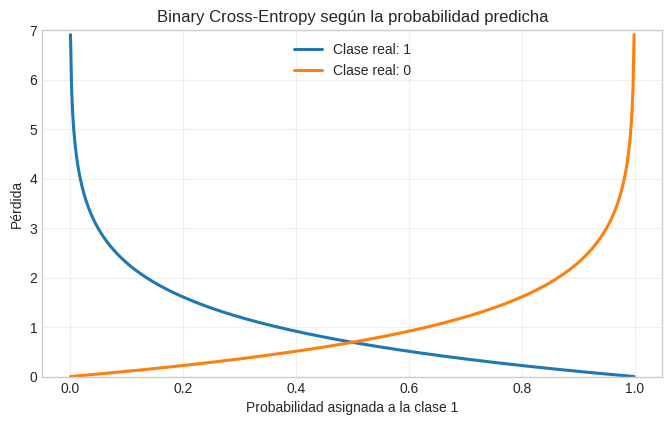

In [6]:
probabilidades_grafico = np.linspace(0.001, 0.999, 500)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    probabilidades_grafico,
    bce_individual(1, probabilidades_grafico),
    label="Clase real: 1",
    linewidth=2.2,
)
ax.plot(
    probabilidades_grafico,
    bce_individual(0, probabilidades_grafico),
    label="Clase real: 0",
    linewidth=2.2,
)
ax.set_title("Binary Cross-Entropy según la probabilidad predicha")
ax.set_xlabel("Probabilidad asignada a la clase 1")
ax.set_ylabel("Pérdida")
ax.set_ylim(0, 7)
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Las dos curvas son simétricas. En ambos casos, la pérdida crece con rapidez cuando la probabilidad se acerca con mucha confianza a la clase equivocada.

## 4. Pérdida y *accuracy* no responden la misma pregunta

Con un umbral de `0.5`, dos modelos pueden asignar la clase correcta a todos los ejemplos y obtener la misma *accuracy*. Sin embargo, sus probabilidades pueden ser muy diferentes. Compararemos un modelo seguro con otro cuyas decisiones apenas superan el umbral.

In [7]:
y_real_binario = np.array([1, 1, 0, 0])

prob_modelo_seguro = np.array([0.99, 0.95, 0.05, 0.02])
prob_modelo_ajustado = np.array([0.51, 0.55, 0.49, 0.45])

def accuracy_binaria(y, probabilidades, umbral=0.5):
    clases_predichas = (probabilidades >= umbral).astype(int)
    return np.mean(clases_predichas == y)

def bce_promedio(y, probabilidades):
    return np.mean(bce_individual(y, probabilidades))

comparacion_binaria = pd.DataFrame({
    "Modelo": ["Predicciones seguras", "Predicciones cercanas al umbral"],
    "Accuracy": [
        accuracy_binaria(y_real_binario, prob_modelo_seguro),
        accuracy_binaria(y_real_binario, prob_modelo_ajustado),
    ],
    "BCE": [
        bce_promedio(y_real_binario, prob_modelo_seguro),
        bce_promedio(y_real_binario, prob_modelo_ajustado),
    ],
})

display(comparacion_binaria)

,Modelo,Accuracy,BCE
0,Predicciones seguras,1.0000,0.0332
1,Predicciones cercanas al umbral,1.0000,0.6356


Ambos modelos alcanzan una *accuracy* de `1.00` en este pequeño conjunto. Esa cifra no significa que sean perfectos en otros datos ni que sus predicciones sean equivalentes.

Binary Cross-Entropy sí distingue los dos casos: las probabilidades seguras y correctas producen una pérdida mucho menor. La pérdida ofrece una señal gradual incluso cuando la clase final todavía no cambia.

## 5. Categorical Cross-Entropy para varias clases

En clasificación multiclase con softmax, las probabilidades suman 1. Si el objetivo está codificado en *one-hot*, la pérdida es:

$$L=-\sum_{i=1}^{K} y_i\log(\hat{y}_i)$$

Como una sola posición del objetivo vale 1, el cálculo equivale a tomar el logaritmo negativo de la probabilidad asignada a la clase correcta.

Supongamos tres clases: `gato`, `perro` y `caballo`, y que la clase correcta es `gato`.

In [8]:
clases = ["gato", "perro", "caballo"]
indice_correcto = 0

predicciones = {
    "A": np.array([0.90, 0.08, 0.02]),
    "B": np.array([0.60, 0.25, 0.15]),
    "C": np.array([0.05, 0.80, 0.15]),
}

filas = []
for nombre, probabilidades in predicciones.items():
    filas.append({
        "Predicción": nombre,
        "P(gato)": probabilidades[0],
        "P(perro)": probabilidades[1],
        "P(caballo)": probabilidades[2],
        "Clase elegida": clases[np.argmax(probabilidades)],
        "Categorical CE": -np.log(probabilidades[indice_correcto]),
    })

tabla_cce = pd.DataFrame(filas)
display(tabla_cce)

,Predicción,P(gato),P(perro),P(caballo),Clase elegida,Categorical CE
0,A,0.9000,0.0800,0.0200,gato,0.1054
1,B,0.6000,0.2500,0.1500,gato,0.5108
2,C,0.0500,0.8000,0.1500,perro,2.9957


La Predicción A asigna `0.90` a la clase correcta y obtiene la menor pérdida, aproximadamente `0.105`. La Predicción B también elige `gato`, pero con menor confianza y una pérdida mayor. La Predicción C elige una clase incorrecta y deja apenas `0.05` para `gato`; por eso su pérdida se aproxima a `2.996`.

### Etiquetas *one-hot* y etiquetas enteras

Podemos comprobar que, para una misma observación, usar el vector *one-hot* de la clase correcta o seleccionar su índice entero conduce al mismo valor matemático.

In [9]:
objetivo_one_hot = np.array([1, 0, 0])
objetivo_entero = 0
probabilidades = np.array([0.70, 0.20, 0.10])

perdida_categorical = -np.sum(objetivo_one_hot * np.log(probabilidades))
perdida_sparse = -np.log(probabilidades[objetivo_entero])

print(f"Con objetivo one-hot: {perdida_categorical:.6f}")
print(f"Con objetivo entero:  {perdida_sparse:.6f}")

Con objetivo one-hot: 0.356675
Con objetivo entero:  0.356675


Ambos cálculos producen aproximadamente `0.356675`. En Keras, la representación del objetivo determina si corresponde `categorical_crossentropy` o `sparse_categorical_crossentropy`; la idea central sigue siendo penalizar una probabilidad baja para la clase correcta.

## 6. Relacionar salida y función de pérdida

La activación final determina la forma de la salida, y la función de pérdida debe ser compatible con esa salida y con la representación del objetivo.

| Tipo de problema | Activación de salida | Pérdida habitual |
|---|---|---|
| Regresión | Lineal | `mse` |
| Clasificación binaria | Sigmoid | `binary_crossentropy` |
| Multiclase con objetivos *one-hot* | Softmax | `categorical_crossentropy` |
| Multiclase con etiquetas enteras | Softmax | `sparse_categorical_crossentropy` |
| Clasificación multietiqueta | Sigmoid | `binary_crossentropy` |

Estas combinaciones son referencias habituales, no una invitación a comparar sus valores numéricos entre sí. Un MSE de `25` y una BCE de `0.4` pertenecen a escalas y problemas diferentes.

## 7. La pérdida como función de un parámetro

El capítulo propone pensar la pérdida como un paisaje. Vamos a observar una versión muy sencilla de esa idea.

Usaremos un modelo con un único peso:

$$\hat{y}=w x$$

Para cada valor posible de $w$, calcularemos las predicciones y su MSE. Solamente exploraremos el paisaje: todavía no aplicaremos gradientes ni actualizaremos el peso.

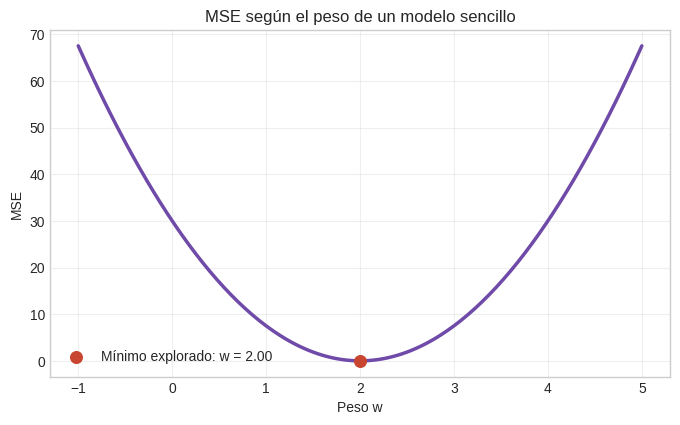

Peso con menor pérdida en la exploración: 2.00
MSE correspondiente: 0.00


In [10]:
x = np.array([1, 2, 3, 4])
y_real = np.array([2, 4, 6, 8])

pesos_posibles = np.linspace(-1, 5, 241)
perdidas = []

for peso in pesos_posibles:
    y_pred = peso * x
    perdidas.append(mse(y_real, y_pred))

perdidas = np.array(perdidas)
indice_minimo = np.argmin(perdidas)
peso_minimo = pesos_posibles[indice_minimo]
perdida_minima = perdidas[indice_minimo]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(pesos_posibles, perdidas, color="#6f4aa8", linewidth=2.5)
ax.scatter(
    peso_minimo,
    perdida_minima,
    color="#c84630",
    s=70,
    label=f"Mínimo explorado: w = {peso_minimo:.2f}",
    zorder=3,
)
ax.set_title("MSE según el peso de un modelo sencillo")
ax.set_xlabel("Peso w")
ax.set_ylabel("MSE")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print(f"Peso con menor pérdida en la exploración: {peso_minimo:.2f}")
print(f"MSE correspondiente: {perdida_minima:.2f}")

El menor valor explorado aparece en `w = 2.00`, donde el modelo reproduce exactamente estos cuatro datos y el MSE es `0.00`. Si cambiamos el peso, cambian las predicciones y también la pérdida.

Aquí encontramos el mínimo probando muchos valores de forma deliberada. En una red real habría una enorme cantidad de parámetros y este procedimiento no sería práctico. El capítulo siguiente presentará una manera más sistemática de decidir en qué dirección modificarlos.

## 8. Actividad breve

Modificá las probabilidades de los dos modelos siguientes. Intentá mantener todas las clases predichas correctamente y, al mismo tiempo, reducir Binary Cross-Entropy.

Observá que *accuracy* solo cambia cuando alguna probabilidad cruza el umbral de `0.5`, mientras que BCE responde también a modificaciones más pequeñas.

In [11]:
y_actividad = np.array([1, 0, 1, 0])

# Modificá estos valores y volvé a ejecutar la celda.
probabilidades_1 = np.array([0.70, 0.30, 0.65, 0.20])
probabilidades_2 = np.array([0.90, 0.10, 0.85, 0.05])

resultados_actividad = pd.DataFrame({
    "Conjunto": ["Probabilidades 1", "Probabilidades 2"],
    "Accuracy": [
        accuracy_binaria(y_actividad, probabilidades_1),
        accuracy_binaria(y_actividad, probabilidades_2),
    ],
    "BCE": [
        bce_promedio(y_actividad, probabilidades_1),
        bce_promedio(y_actividad, probabilidades_2),
    ],
})

display(resultados_actividad)

,Conjunto,Accuracy,BCE
0,Probabilidades 1,1.0000,0.3418
1,Probabilidades 2,1.0000,0.1061


Con los valores iniciales, ambos conjuntos clasifican correctamente las cuatro observaciones y alcanzan una *accuracy* de `1.00`. El segundo obtiene una BCE menor porque asigna probabilidades más altas a las clases correctas.

Esta actividad no busca que todas las probabilidades se vuelvan extremas sin analizar el contexto. Su objetivo es mostrar que la pérdida conserva información que desaparece al convertir probabilidades en clases.

## Cierre

En este cuaderno convertimos la diferencia entre valores reales y predicciones en medidas numéricas. MSE resultó adecuado para comparar valores continuos y mostró una penalización creciente para los errores grandes. Binary Cross-Entropy evaluó probabilidades en clasificación binaria, mientras que Categorical Cross-Entropy hizo lo propio con distribuciones entre varias clases.

También comprobamos que pérdida y métrica cumplen funciones diferentes. Dos modelos pueden compartir la misma *accuracy* y, aun así, producir pérdidas distintas. Finalmente observamos un paisaje de pérdida muy sencillo: al cambiar un peso, cambian las predicciones y el MSE.

Ya sabemos medir qué tan mala es una predicción. El siguiente paso será estudiar cómo utilizar esa información para modificar los parámetros: **descenso por gradiente**.

## Para pensar

1. ¿Por qué no conviene promediar directamente los errores con signo en un problema de regresión?
2. Si dos modelos tienen la misma *accuracy*, ¿qué información adicional puede aportar Binary Cross-Entropy?
3. ¿Por qué no tiene sentido afirmar que una BCE de `0.4` es mejor que un MSE de `25` solamente porque el primer número es menor?

---

### Autoría y atribución

Este cuaderno forma parte del material educativo desarrollado por **VintaBytes**.

📧 **Contacto:** [vintabytes@gmail.com](mailto:vintabytes@gmail.com)

🌐 **Repositorio oficial:** [github.com/VintaBytes/Ciencia-de-datos](https://github.com/VintaBytes/Ciencia-de-datos)

Se permite compartir y reutilizar este material respetando la autoría y manteniendo visible esta atribución.

---
